# Real-World Data Project — Retail Sales Analysis & Forecasting

**Domain:** Retail

**Goal:** Perform end-to-end analysis of a retail sales dataset, uncover trends across time, 
category, weekday, and promotions, then build a simple predictive model to forecast daily revenue.

**Dataset:** two years of daily sales across 5 categories and 5 cities (3665 raw rows).

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')
df = pd.read_csv('../data/retail_sales_dataset.csv', parse_dates=['Date'])
print(df.shape)
df.head()

(3665, 9)


        Date     Category       City  Units_Sold  Unit_Price  Revenue  Customer_Count  Avg_Customer_Age  Promotion
0 2024-01-01  Electronics  Hyderabad          15      238.87  3583.05              10              25.1          0
1 2024-01-01     Clothing     Mumbai          38       43.60  1656.80              25              38.6          0
2 2024-01-01    Groceries  Hyderabad         100       11.98  1198.00              53              21.6          0
3 2024-01-01    Furniture    Chennai           0        0.00     0.00               1              22.3          0
4 2024-01-01         Toys  Hyderabad          22       29.72   653.84              13              29.6          0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              3665 non-null   datetime64[us]
 1   Category          3665 non-null   str           
 2   City              3665 non-null   str           
 3   Units_Sold        3665 non-null   int64         
 4   Unit_Price        3665 non-null   float64       
 5   Revenue           3665 non-null   float64       
 6   Customer_Count    3665 non-null   int64         
 7   Avg_Customer_Age  3635 non-null   float64       
 8   Promotion         3665 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(3), str(2)
memory usage: 257.8 KB


## 2. Data Cleaning

- Removed duplicate rows introduced by a data pipeline artifact.
- `Unit_Price` had implausible zero values, treated as missing and imputed with the category median.
- `Avg_Customer_Age` had missing values, imputed with the category median.
- Recomputed `Revenue = Units_Sold * Unit_Price` after price imputation.
- Engineered `Month`, `Weekday`, `Is_Weekend`, and `Promotion_Label` for analysis.

In [3]:
before = len(df)
df = df.drop_duplicates()
df['Unit_Price'] = df['Unit_Price'].replace(0, np.nan)
df['Unit_Price'] = df.groupby('Category')['Unit_Price'].transform(lambda s: s.fillna(s.median()))
df['Revenue'] = df['Units_Sold'] * df['Unit_Price']
df['Avg_Customer_Age'] = df.groupby('Category')['Avg_Customer_Age'].transform(lambda s: s.fillna(s.median()))
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.day_name()
df['Is_Weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)
df['Promotion_Label'] = df['Promotion'].map({0:'No Promotion', 1:'Promotion'})
print('Rows after cleaning:', len(df))
df.describe().T

Rows after cleaning: 3650


                   count                 mean                  min                  25%                  50%                  75%                  max          std
Date                3650  2024-12-30 12:00:00  2024-01-01 00:00:00  2024-07-01 00:00:00  2024-12-30 12:00:00  2025-07-01 00:00:00  2025-12-30 00:00:00          NaN
Units_Sold        3650.0            55.371507                  0.0                 19.0                 33.0                 61.0                400.0    57.925052
Unit_Price        3650.0           143.468345                10.13              29.1175                44.81             258.9375               448.82   146.877692
Revenue           3650.0          2844.971953                  0.0              1446.04             2185.785             3759.925             14111.35  2002.530272
Customer_Count    3650.0            32.889589                  1.0                 10.0                 19.0                 39.0                249.0    36.637591
Avg_Customer_Age

## 3. Revenue Trend Over Time

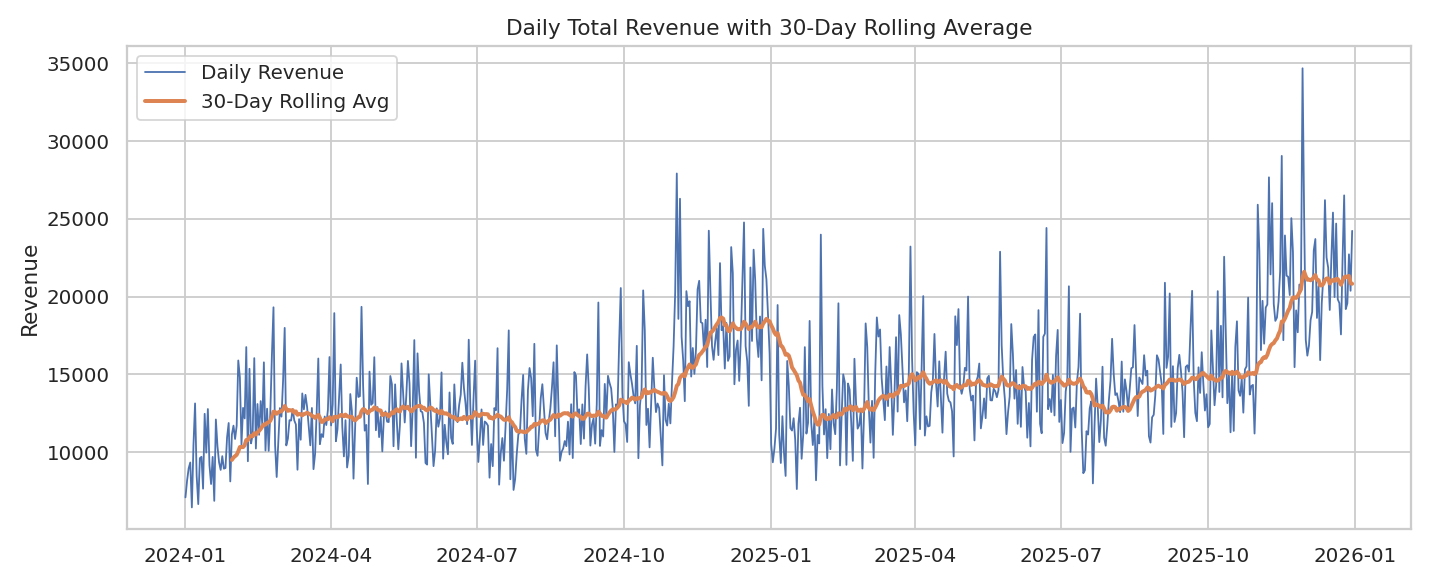

In [4]:
daily_revenue = df.groupby('Date')['Revenue'].sum().reset_index()
fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(daily_revenue['Date'], daily_revenue['Revenue'], color='#4C72B0', linewidth=1)
ax.plot(daily_revenue['Date'], daily_revenue['Revenue'].rolling(30).mean(), color='#DD8452', linewidth=2.2)
ax.set_title('Daily Total Revenue with 30-Day Rolling Average')
ax.legend(['Daily Revenue','30-Day Rolling Avg'])
plt.tight_layout(); plt.show()

## 4. Revenue by Category

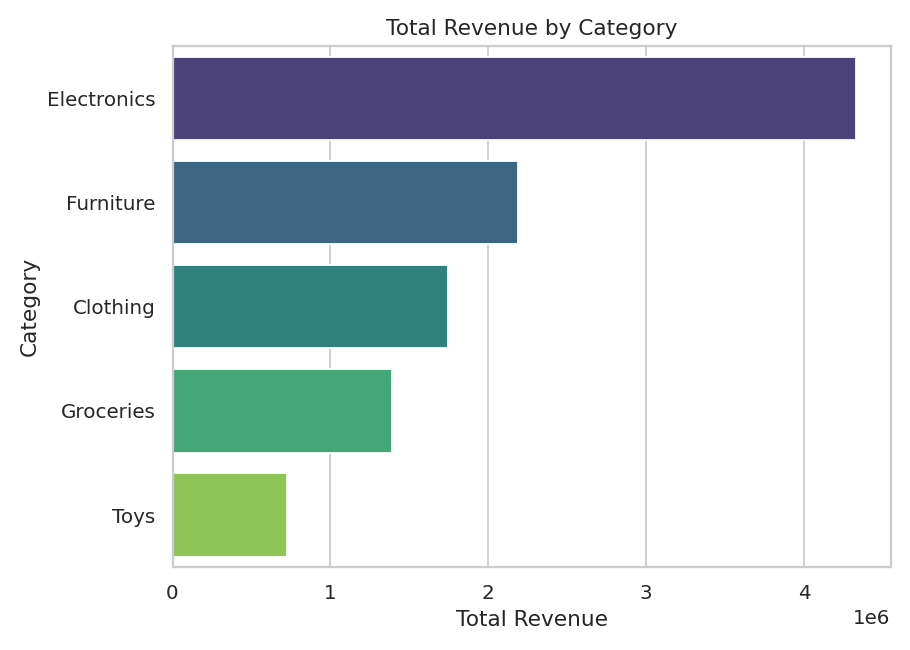

Category
Electronics    4331407.38
Furniture      2189469.56
Clothing       1744531.77
Groceries      1390357.55
Toys            728381.37


In [5]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=category_revenue.values, y=category_revenue.index, hue=category_revenue.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Total Revenue by Category')
plt.tight_layout(); plt.show()

## 5. Weekday Patterns

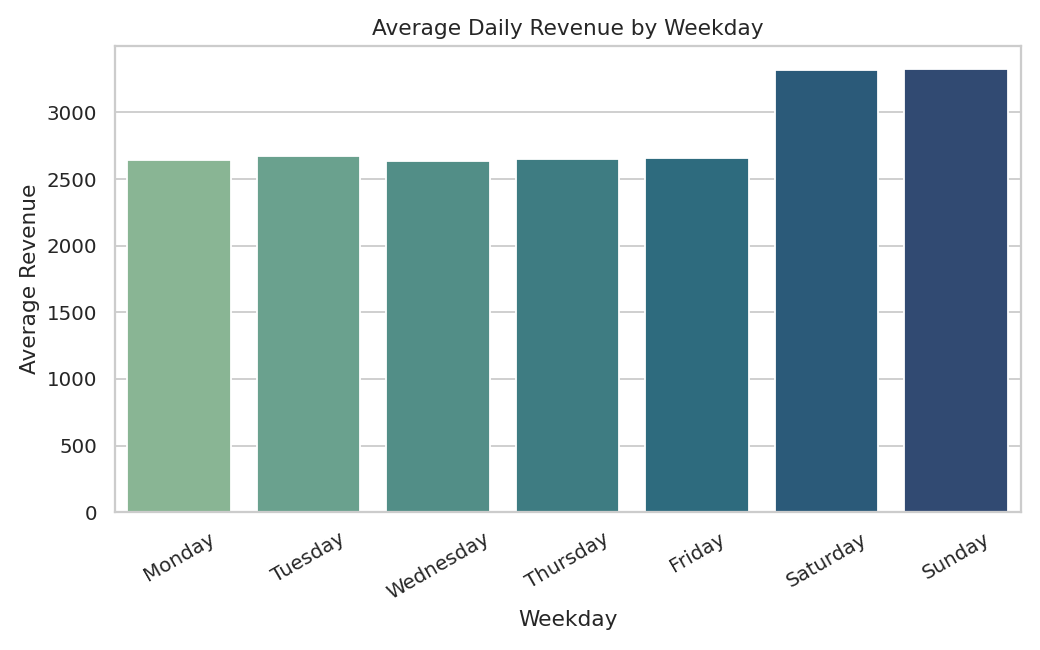

In [6]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_revenue = df.groupby('Weekday')['Revenue'].mean().reindex(order)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=weekday_revenue.index, y=weekday_revenue.values, hue=weekday_revenue.index, palette='crest', legend=False, ax=ax)
ax.set_title('Average Daily Revenue by Weekday')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 6. Promotion Effect

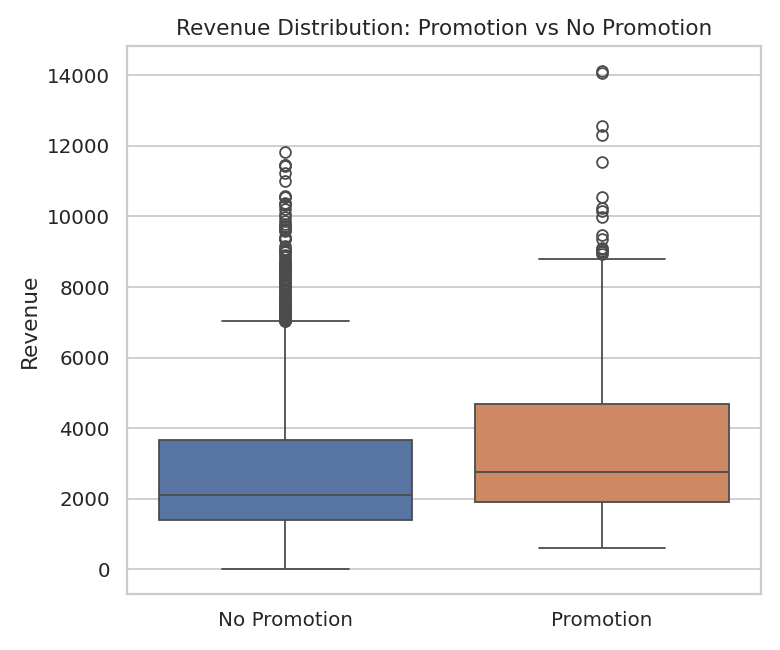

Promotion_Label
No Promotion    2753.084337
Promotion       3624.226675


In [7]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=df, x='Promotion_Label', y='Revenue', hue='Promotion_Label', palette={'No Promotion':'#4C72B0','Promotion':'#DD8452'}, legend=False, ax=ax)
ax.set_title('Revenue Distribution: Promotion vs No Promotion')
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

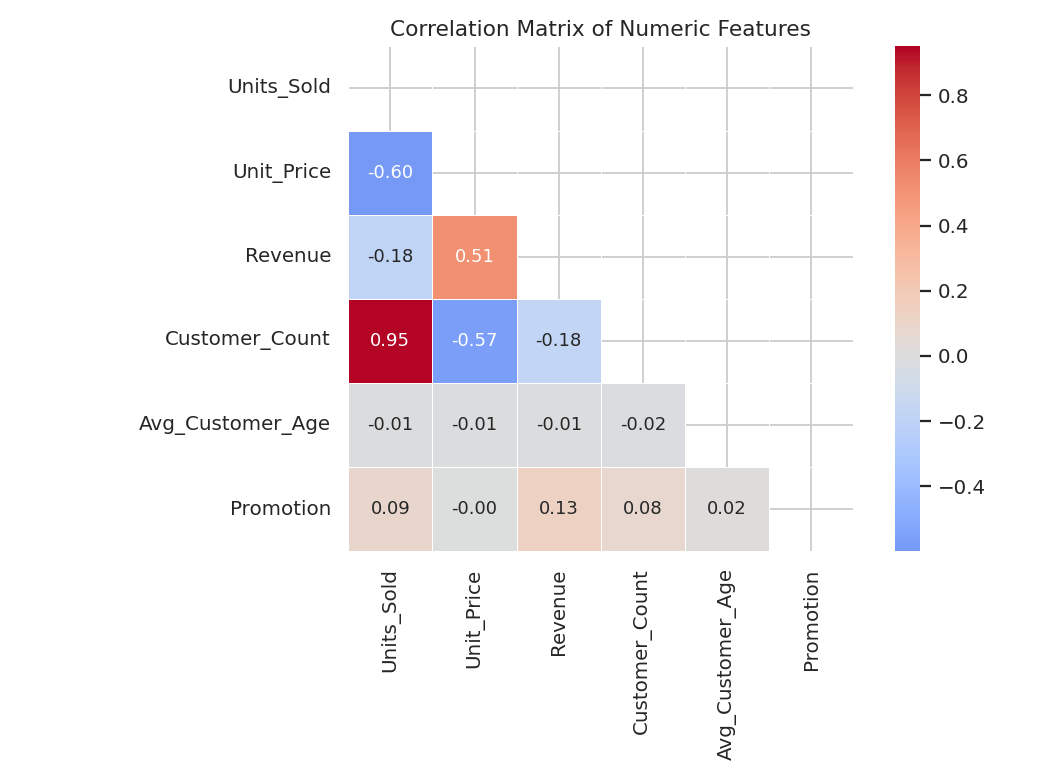

In [8]:
corr_cols = ['Units_Sold','Unit_Price','Revenue','Customer_Count','Avg_Customer_Age','Promotion']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
plt.tight_layout(); plt.show()

## 8. Monthly Revenue

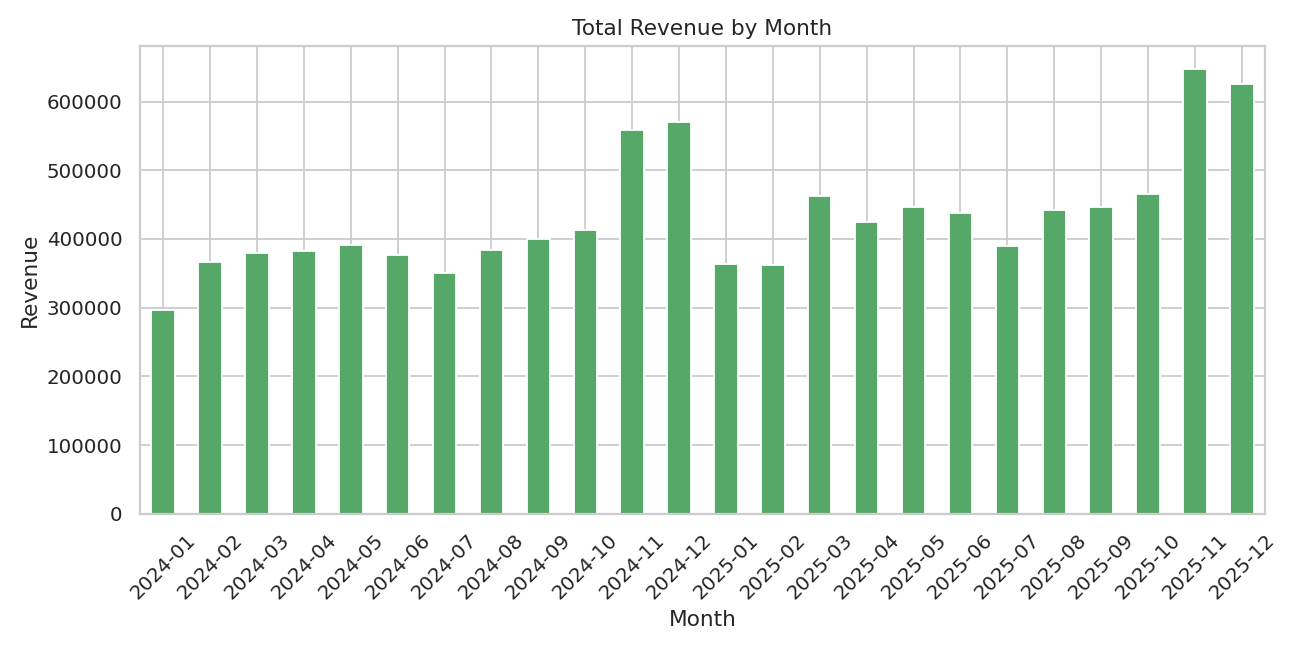

In [9]:
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Revenue'].sum()
fig, ax = plt.subplots(figsize=(10,5))
monthly_revenue.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Total Revenue by Month')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 9. Customers vs Revenue

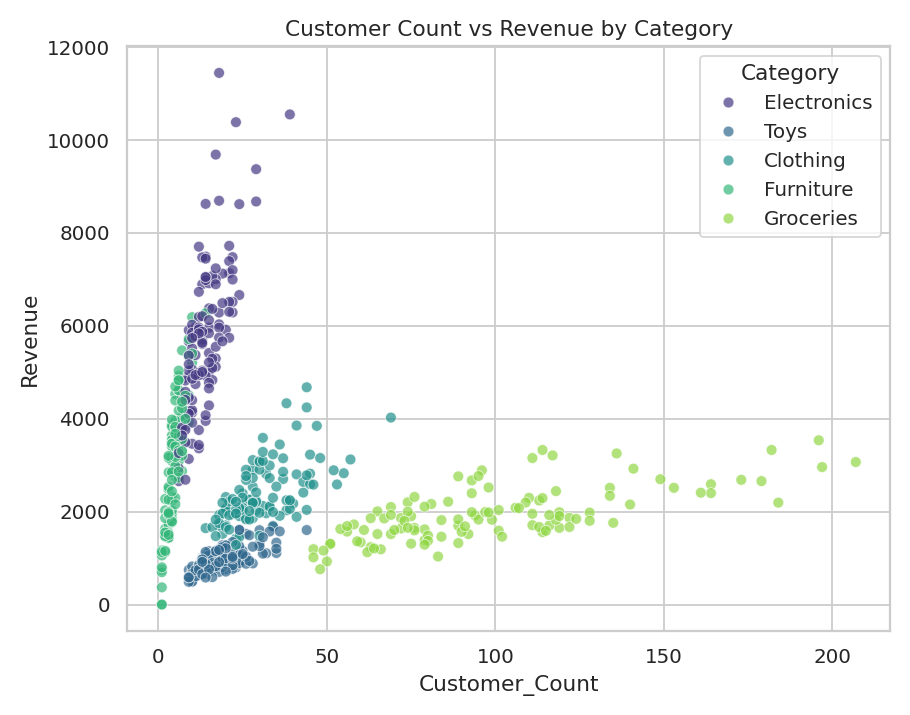

In [10]:
fig, ax = plt.subplots(figsize=(7,5.5))
sns.scatterplot(data=df.sample(600, random_state=1), x='Customer_Count', y='Revenue', hue='Category', palette='viridis', alpha=0.7, ax=ax)
ax.set_title('Customer Count vs Revenue by Category')
plt.tight_layout(); plt.show()

## 10. Category vs Weekday Heatmap

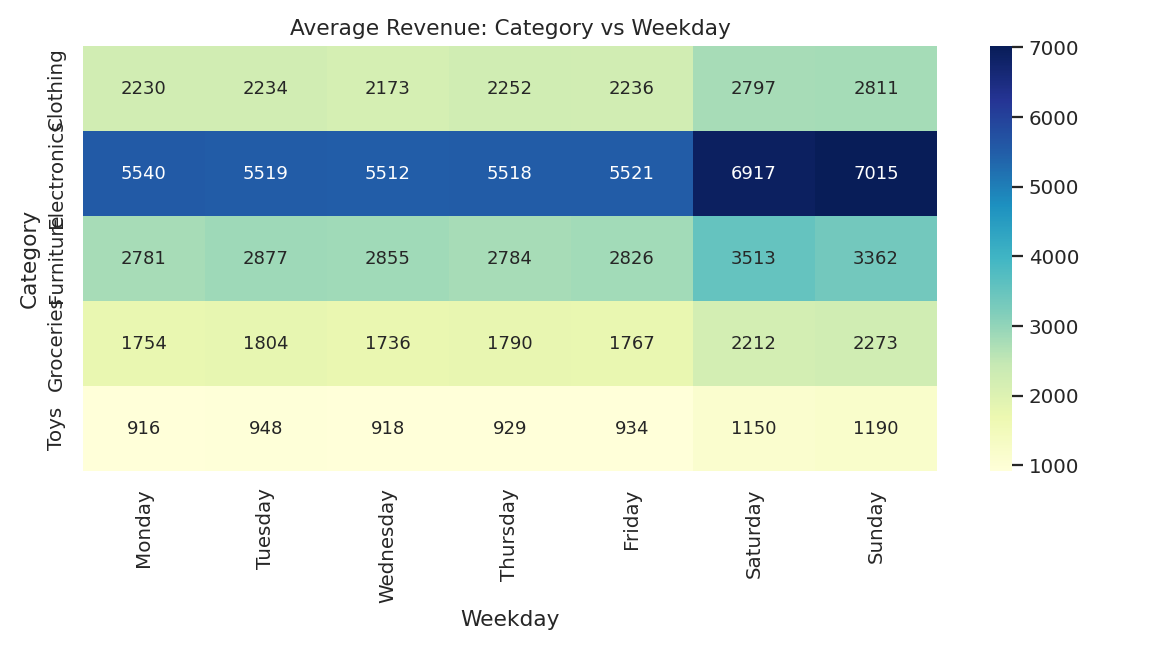

In [11]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(index='Category', columns='Weekday', values='Revenue', aggfunc='mean')[order]
fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
plt.tight_layout(); plt.show()

## 11. Sales Prediction Model

A RandomForestRegressor is trained on daily category-level sales to forecast `Revenue`, using 
calendar features, promotion flag, category, and lagged revenue (previous day and previous week) 
as predictors. The last 15% of the timeline is held out as a test set to simulate forecasting 
unseen future days.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

daily = df.groupby(['Date','Category'], as_index=False).agg(
    Revenue=('Revenue','sum'), Units_Sold=('Units_Sold','sum'),
    Customer_Count=('Customer_Count','sum'), Promotion=('Promotion','max'))
daily['Month'] = daily['Date'].dt.month
daily['Weekday_Num'] = daily['Date'].dt.dayofweek
daily['Is_Weekend'] = (daily['Weekday_Num'] >= 5).astype(int)
daily['Day_Index'] = (daily['Date'] - daily['Date'].min()).dt.days
daily = daily.sort_values(['Category','Date'])
daily['Revenue_Lag1'] = daily.groupby('Category')['Revenue'].shift(1)
daily['Revenue_Lag7'] = daily.groupby('Category')['Revenue'].shift(7)
daily = daily.dropna().reset_index(drop=True)

cat_dummies = pd.get_dummies(daily['Category'], prefix='Cat')
features = pd.concat([daily[['Month','Weekday_Num','Is_Weekend','Promotion','Day_Index','Revenue_Lag1','Revenue_Lag7']], cat_dummies], axis=1)
target = daily['Revenue']

split_date = daily['Date'].quantile(0.85, interpolation='nearest')
train_mask = daily['Date'] <= split_date
X_train, X_test = features[train_mask], features[~train_mask]
y_train, y_test = target[train_mask], target[~train_mask]

model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
print(f'MAE={mae:.2f} RMSE={rmse:.2f} R2={r2:.4f}')

MAE=676.56 RMSE=1051.84 R2=0.8165


### 11.1 Feature Importance

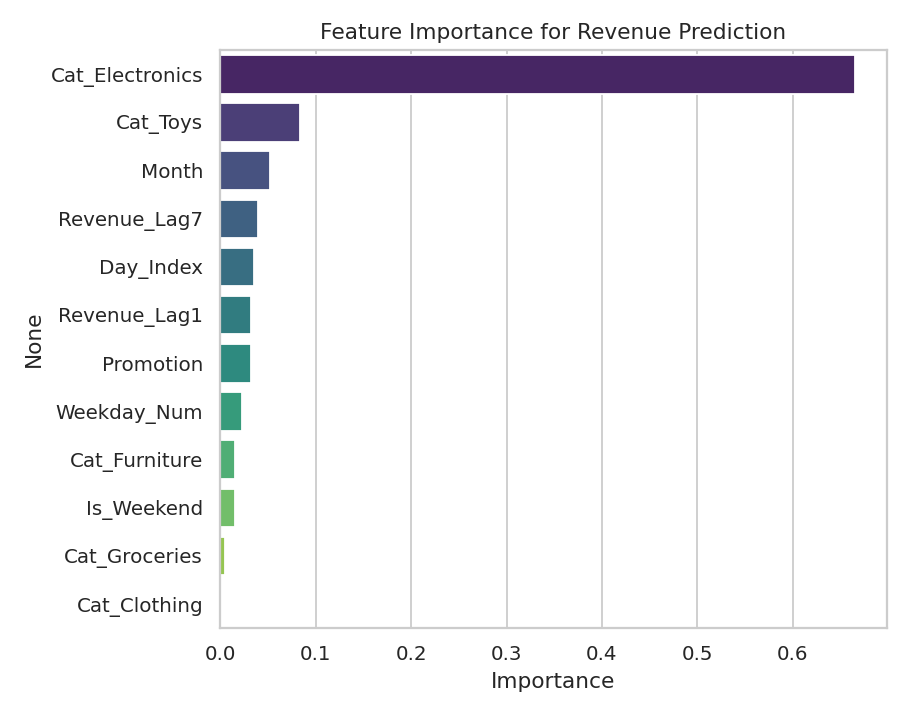

In [13]:
importances = pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,5.5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Feature Importance for Revenue Prediction')
plt.tight_layout(); plt.show()

### 11.2 Actual vs Predicted Revenue

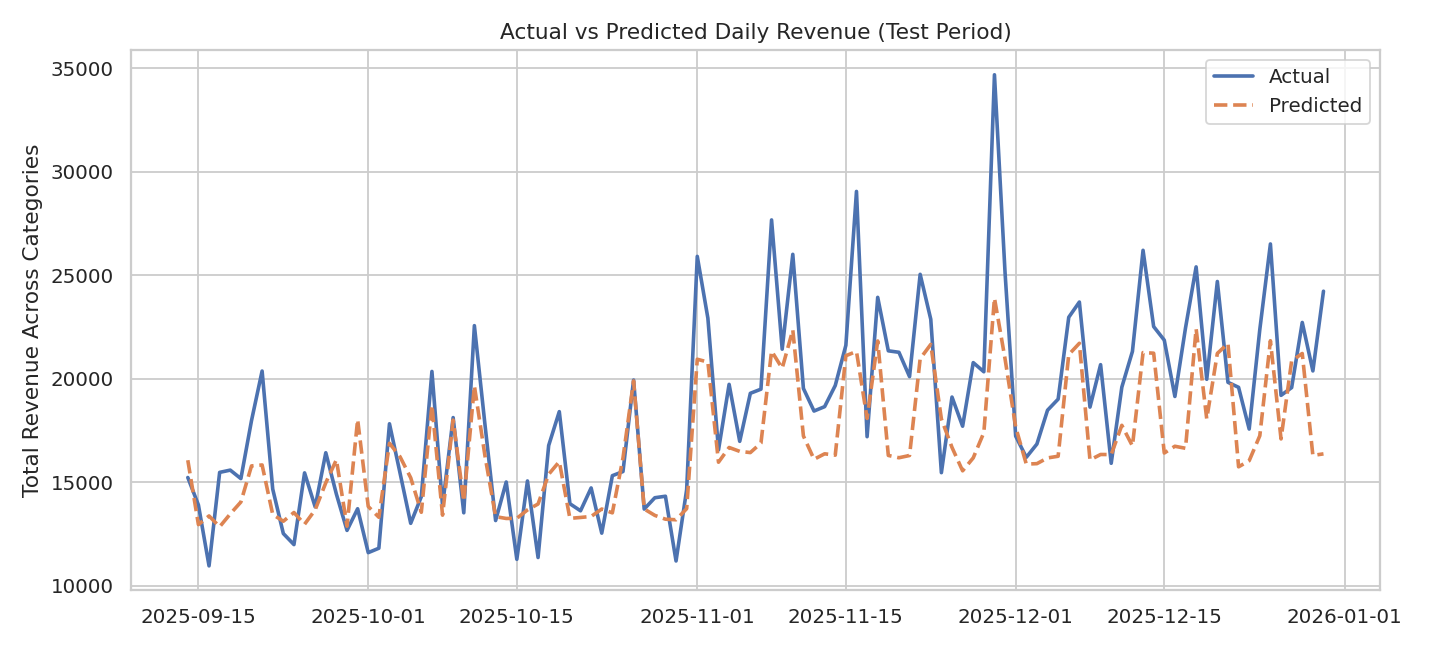

In [14]:
results_df = daily[~train_mask][['Date','Category']].copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = preds
agg_actual = results_df.groupby('Date')['Actual'].sum()
agg_pred = results_df.groupby('Date')['Predicted'].sum()
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(agg_actual.index, agg_actual.values, label='Actual', color='#4C72B0', linewidth=2)
ax.plot(agg_pred.index, agg_pred.values, label='Predicted', color='#DD8452', linewidth=2, linestyle='--')
ax.set_title('Actual vs Predicted Daily Revenue (Test Period)')
ax.legend(); plt.tight_layout(); plt.show()

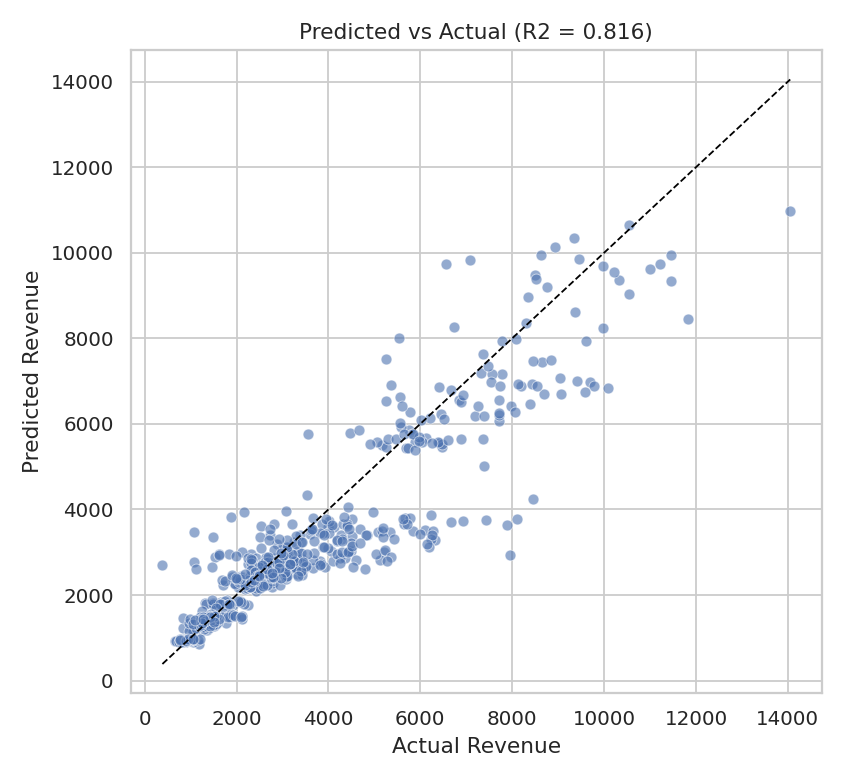

In [15]:
fig, ax = plt.subplots(figsize=(6.5,6))
sns.scatterplot(x=y_test, y=preds, alpha=0.6, ax=ax, color='#4C72B0')
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Actual Revenue'); ax.set_ylabel('Predicted Revenue')
ax.set_title(f'Predicted vs Actual (R2 = {r2:.3f})')
plt.tight_layout(); plt.show()

## 12. Summary of Findings

- **Electronics** and **Furniture** generate the highest total revenue despite lower unit volumes, 
  driven by higher price points.
- **Weekends** consistently produce higher average daily revenue than weekdays across all categories.
- **Promotions** lift average daily revenue noticeably (roughly +30% on promoted days).
- **November-December** shows the strongest seasonal spike, consistent with holiday shopping behavior.
- The Random Forest model explains about **82% of the variance** in daily category revenue 
  (R² ≈ 0.82), with the previous week's revenue, previous day's revenue, and day-of-year position 
  as the most important predictors.
- The model **underpredicts the holiday season spike**, since it had limited prior examples of 
  November/December in the training window — a common real-world forecasting limitation that would 
  improve with more historical years of data.

**Conclusion:** category, weekday, and promotion are strong, consistent drivers of retail revenue, 
and a lightweight lag-based model captures the overall pattern well, though holiday-season extremes 
remain the hardest part of the year to forecast accurately.